# Make Predictions

In [1]:
import os
import sys
sys.path.append('../')
import time
import torch
import skimage
import sklearn.metrics
import wandb

import numpy as np
import matplotlib.pyplot as plt

import mnds
import mnmodel
import evaluation

# Hyperparameter setting

In [2]:
CURRENT_PATH = os.getcwd()
DIRECTORY = CURRENT_PATH + '/all_data_micronuclei_no_rescale/train'
OUTPUT_DIR = "/model_output/output/"

# set CHTC writeable cache directory for pytorch and matplotlib
os.environ['TORCH_HOME'] = CURRENT_PATH + '/.cache/torch'
os.environ['MPLCONFIGDIR'] = CURRENT_PATH + '/.cache/matplotlib/config'
torch.set_num_threads(8)

SCALE_FACTOR = 1.0
PATCH_SIZE = 256
FEATURE_SIZE = 384
# STEP = 16
EPOCHS = 20
THRESHOLD = 0.5

LOSS_FN = 'combined'
LR = 1e-5
BATCH_SIZE = 4
FINETUNE = True
WEIGHT_DECAY = 1e-6

gpu = 0
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'

# Load Model

In [3]:
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

predictions_dir = DIRECTORY + OUTPUT_DIR
models_dir = OUTPUT_DIR

model = mnmodel.MicronucleiModel(
    data_dir=CURRENT_PATH + '/all_data_micronuclei_no_rescale/train',
    device=device
)
model.load('DinoMN_oversampled.pth', model_dir=models_dir)

Using cache found in /scr/yren/micronuclei-detection/src/dinomn/.cache/torch/hub/facebookresearch_dinov2_main
/scr/yren/micronuclei-detection/src/dinomn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/scr/yren/micronuclei-detection/src/dinomn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/scr/yren/micronuclei-detection/src/dinomn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/scr/yren/micronuclei-detection/src/dinomn/mnmodel.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to 

In [4]:
model.device

'cuda:0'

# Make Predictions

(2960, 2960)


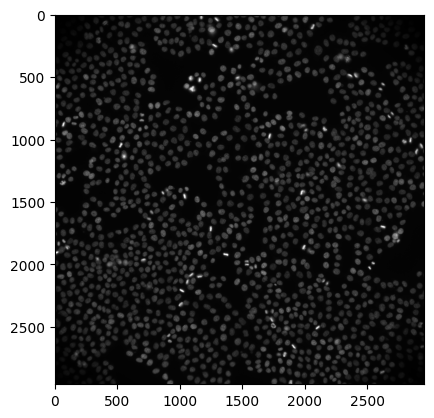

In [5]:
image = 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif'
im = skimage.io.imread(f'/scr/yren/micronuclei-detection/src/dinomn/all_data_micronuclei_no_rescale/validation/{image}')
print(im.shape)
plt.imshow(im, cmap='gray')
# plt.imshow(im[:,:,0])

In [6]:
im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")

In [8]:
STEP=32
probabilities = model.predict(im, stride=1, step=STEP, batch_size=BATCH_SIZE)

/scr/yren/micronuclei-detection/src/dinomn/mnmodel.py:375: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


In [9]:
predictions_dir = DIRECTORY.replace('train', 'validation') + OUTPUT_DIR
predictions_dir

'/scr/yren/micronuclei-detection/src/dinomn/all_data_micronuclei_no_rescale/validation/model_output/output/'

In [10]:
print(probabilities.shape)

(2, 2960, 2960)


In [11]:
validation_file = image.replace('.phenotype.tif', 'phenotype_outlines.png')
mn_filename = predictions_dir + validation_file.replace('phenotype_outlines.png','_mn_probabilities')
n_filename = predictions_dir + validation_file.replace('phenotype_outlines.png','_nuc_probabilities')
mn_pred = probabilities[0,:,:] > THRESHOLD
n_pred = probabilities[1,:,:] > THRESHOLD

labeled_mn = skimage.morphology.label(mn_pred)
labeled_mn = np.asarray(labeled_mn, dtype='uint16')

labeled_n = skimage.morphology.label(n_pred)
labeled_n = np.asarray(labeled_n, dtype='uint16')

np.save(mn_filename, labeled_mn)
np.save(n_filename, labeled_n)

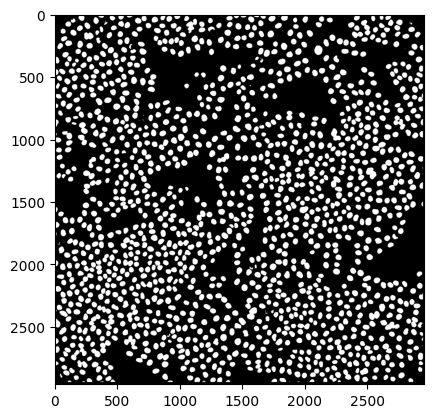

In [12]:
plt.imshow(labeled_n > 0, cmap='gray')

(2, 2960, 2960)


Text(0.5, 1.0, 'Micronuclei Prediction')

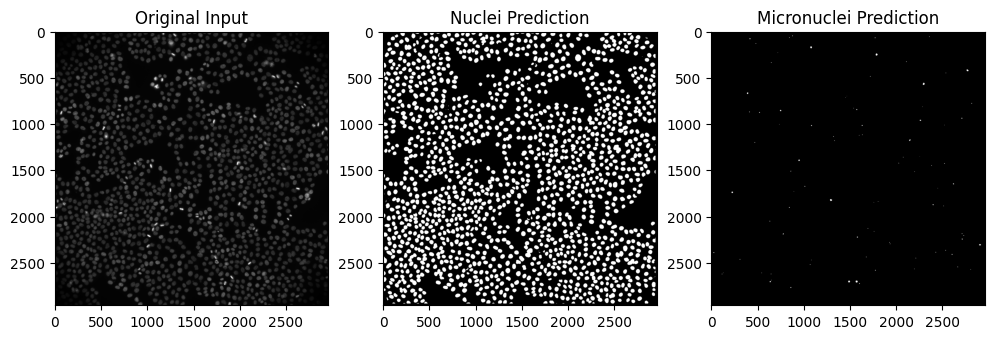

In [13]:
print(probabilities.shape)
nuc_pred = probabilities[1,:,:] > 0.5
mic_pred = probabilities[0,:,:] > 0.5

fig, axs = plt.subplots(1,3,figsize=(12,12))
axs[0].imshow(im, cmap='gray')
axs[0].set_title('Original Input')

axs[1].imshow(nuc_pred, cmap='gray')
axs[1].set_title('Nuclei Prediction')

axs[2].imshow(mic_pred, cmap='gray')
axs[2].set_title('Micronuclei Prediction')